In [1]:
import matplotlib.pyplot as plt

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})


In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from utils.spike_detection import *
from utils.preprocess_neural import *

import matplotlib.pyplot as plt
import matplotlib.cm as cm

import numpy.ma as ma
from scipy.ndimage import gaussian_filter
from tqdm import tqdm
import subprocess
import shutil
import pickle
from matplotlib.backends.backend_pdf import PdfPages

%matplotlib widget

In [3]:
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce21/2025-06-30_pAce21_PR/Awake'
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce9/2025-02-10_pAce9-PX/post-cement/awake/fov1'
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce21/2025-08-06_pAce21_PR/Awake' # Good
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce37/2025-11-12_pAce37_BR/post/Awake' # Finished
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce19/2025-04-21_pAce19/PX/Awake/FOV1' # problem with behavior

#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake' # Good
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce45/2026-01-18_pAce45/PX/post/Awake' # Good
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake' # Good
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce21/2025-08-06_pAce21_PR/Awake' # Good
main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake'

# INs
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce17/2025-03-26_pAce17/PX/short-lens/post-cement/Awake' # WT

######## Interneurons ########
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce17/2025-03-26_pAce17/PX/short-lens/post-cement/Awake' 


In [4]:
# load merged data 
merged_data_path = os.path.join(main_data_folder, 'merged_aligned_data.pkl')
with open(merged_data_path, 'rb') as f:
    loaded_merged_data = pickle.load(f)
    traces = loaded_merged_data['traces']
    spikes = loaded_merged_data['spikes']
    spikes_volpy = loaded_merged_data['spikes_volpy']
    speed = loaded_merged_data['speed']
    ts_neural = loaded_merged_data['ts_neural']
    x_neural = loaded_merged_data['x_neural']
    y_neural = loaded_merged_data['y_neural']
    hd_angles_neural = loaded_merged_data['hd_angles_neural']
    weights_all = loaded_merged_data['weights_all']
    ROIs_all = loaded_merged_data['ROIs_all']
    mean_images = loaded_merged_data['mean_images']
    mean_images_raw = loaded_merged_data['mean_images_raw']
    frame_rate = loaded_merged_data['frame_rate']
    frame_width = loaded_merged_data['frame_width']
    frame_height = loaded_merged_data['frame_height']
    subfolders = loaded_merged_data['subfolders']
    session_start_frames = loaded_merged_data['session_start_frames']
fr = frame_rate


Processing cell 0
Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
Total complex spikes detected: 0
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Window size: 10000, Step size: 5000
Session 1 - Simple Spikes Linear slope: -0.052469
Session 1 - Simple Spikes Exp decay (b): 0.000737
Session 1 - Simple Spikes Tau (1/b): 1357.58 seconds
Session 1 - Baseline Noise Linear slope: -0.004436
Session 1 - Baseline Noise Exp decay (b): 0.001152
Session 1 - Baseline Noise Tau (1/b): 868.06 seconds
Session 1 - SNR Linear slope: -0.001454
Session 1 - SNR Exp decay (b): 0.000000
Session 1 - SNR Tau (1/b): 11560299.13 seconds


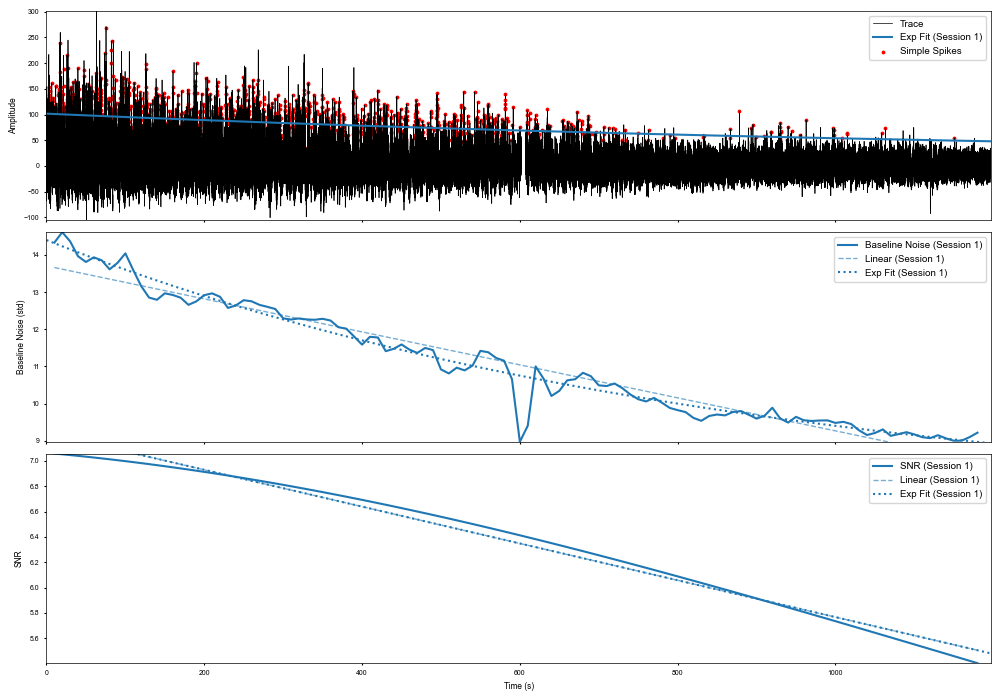

Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
  Found 205 complex spikes in segment 0
Total complex spikes detected: 205
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Removed 174 invalid CS bursts
Moved 33 spikes from single-spike bursts to refined_SS
Remaining CS bursts: 31
Created 3 pages with 240 segments total
Figure saved to: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/SNR_figures/cell_0_burst_detection.pdf

Processing cell 1
Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
Total complex spikes detected: 0
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Window size: 10000, Step size: 5000
Session 1 - Simple Spikes Linear slope: 0.003951
Session 1 - Simple Spikes Exp decay (b): 50.325158
Session 1 - Sim

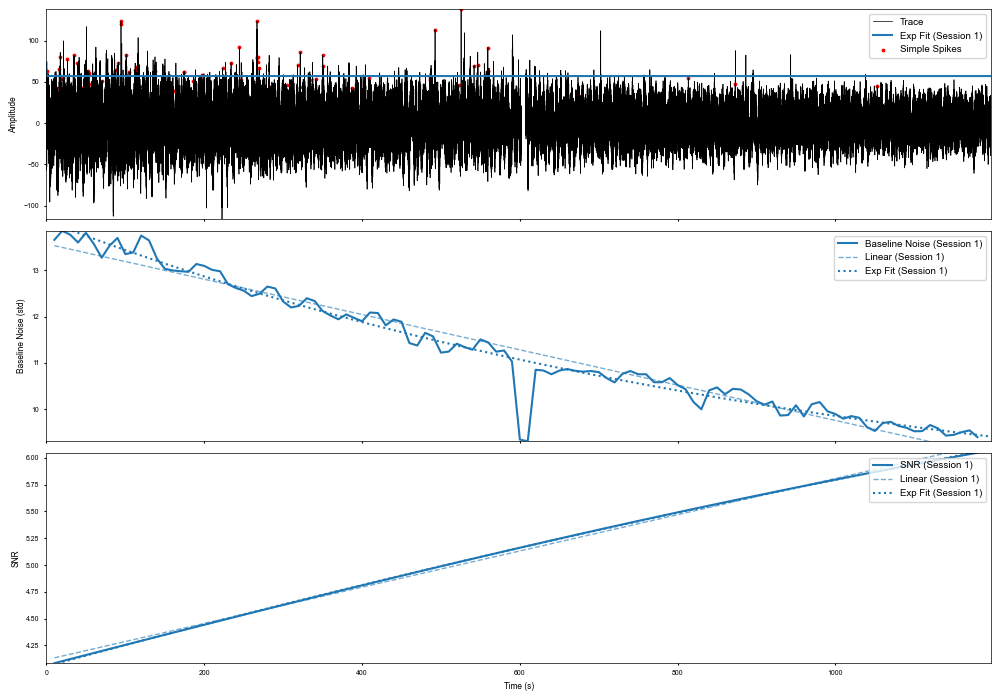

Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
  Found 116 complex spikes in segment 0
Total complex spikes detected: 116
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Removed 105 invalid CS bursts
Moved 7 spikes from single-spike bursts to refined_SS
Remaining CS bursts: 11
Created 3 pages with 240 segments total
Figure saved to: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/SNR_figures/cell_1_burst_detection.pdf

Processing cell 2
Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
Total complex spikes detected: 0
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Window size: 10000, Step size: 5000
Session 1 - Simple Spikes Linear slope: -0.005323
Session 1 - Simple Spikes Exp decay (b): 6.970072
Session 1 - Simp

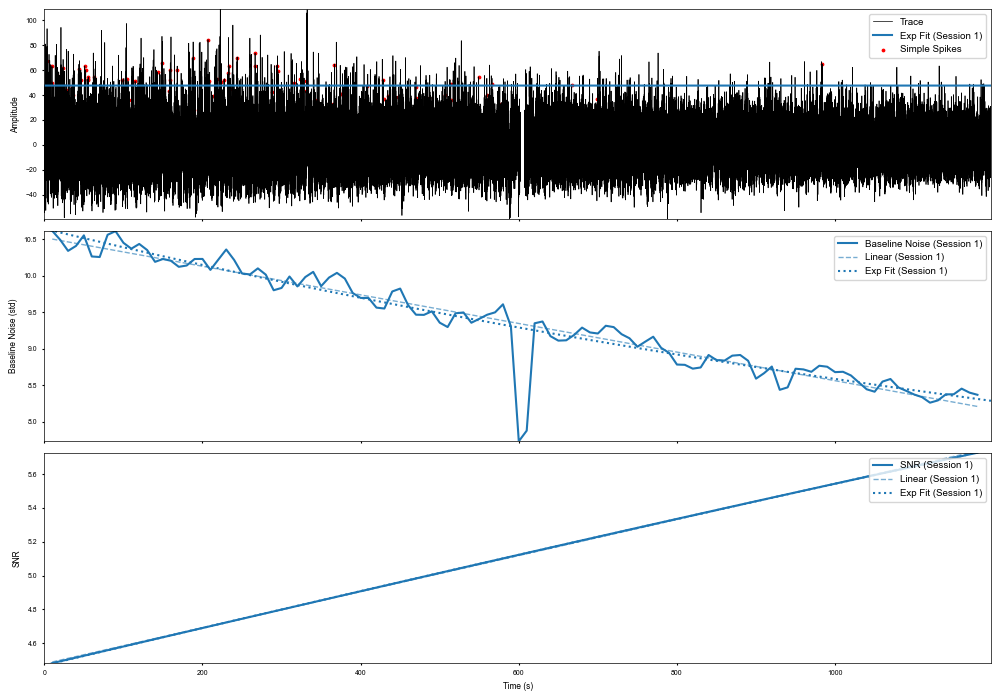

Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
  Found 527 complex spikes in segment 0
Total complex spikes detected: 527
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Removed 489 invalid CS bursts
Moved 23 spikes from single-spike bursts to refined_SS
Remaining CS bursts: 38
Created 3 pages with 240 segments total
Figure saved to: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/SNR_figures/cell_2_burst_detection.pdf

Processing cell 3
Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
Total complex spikes detected: 0
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Window size: 10000, Step size: 5000
Session 1 - Simple Spikes Linear slope: -0.029362
Session 1 - Simple Spikes Exp decay (b): 0.003986
Session 1 - Sim

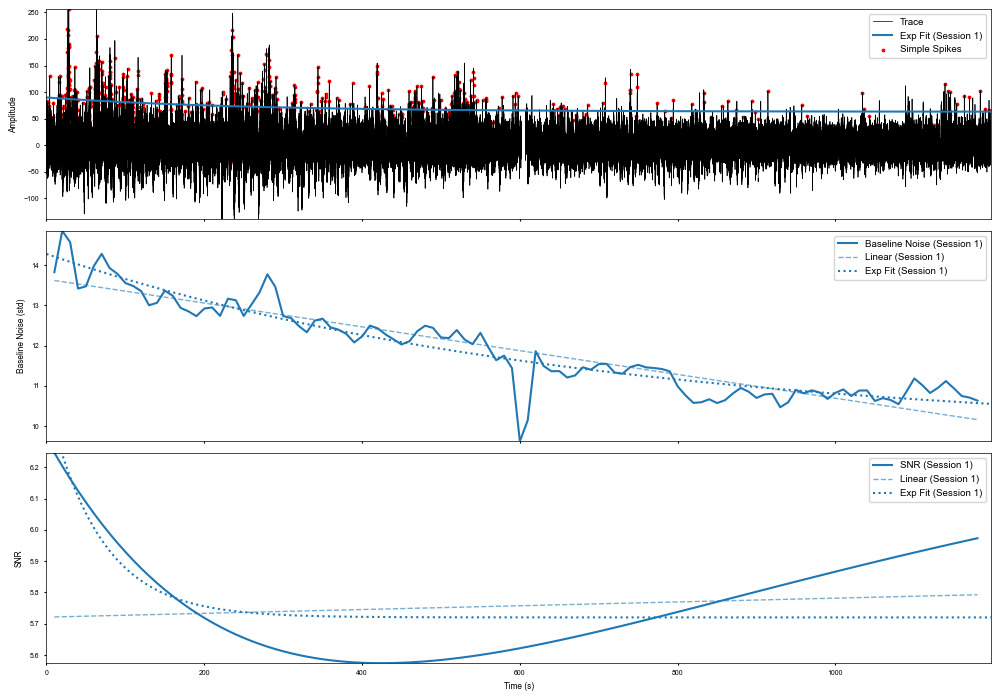

Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
  Found 169 complex spikes in segment 0
Total complex spikes detected: 169
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Removed 109 invalid CS bursts
Moved 24 spikes from single-spike bursts to refined_SS
Remaining CS bursts: 60
Created 3 pages with 240 segments total
Figure saved to: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/SNR_figures/cell_3_burst_detection.pdf

Processing cell 4
Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
Total complex spikes detected: 0
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Window size: 10000, Step size: 5000
Session 1 - Simple Spikes Linear slope: -0.022281
Session 1 - Simple Spikes Exp decay (b): 8.065160
Session 1 - Sim

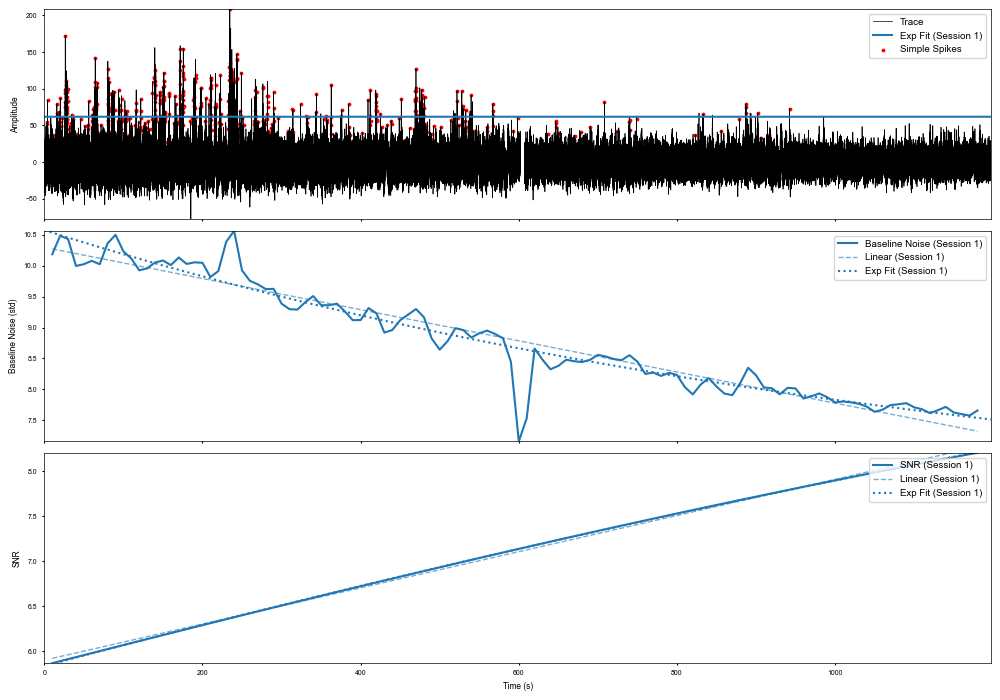

Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
  Found 226 complex spikes in segment 0
Total complex spikes detected: 226
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Removed 135 invalid CS bursts
Moved 18 spikes from single-spike bursts to refined_SS
Remaining CS bursts: 91
Created 3 pages with 240 segments total
Figure saved to: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/SNR_figures/cell_4_burst_detection.pdf

Processing cell 5
Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
Total complex spikes detected: 0
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Window size: 10000, Step size: 5000
Session 1 - Simple Spikes Linear slope: -0.020527
Session 1 - Simple Spikes Exp decay (b): 0.000261
Session 1 - Sim

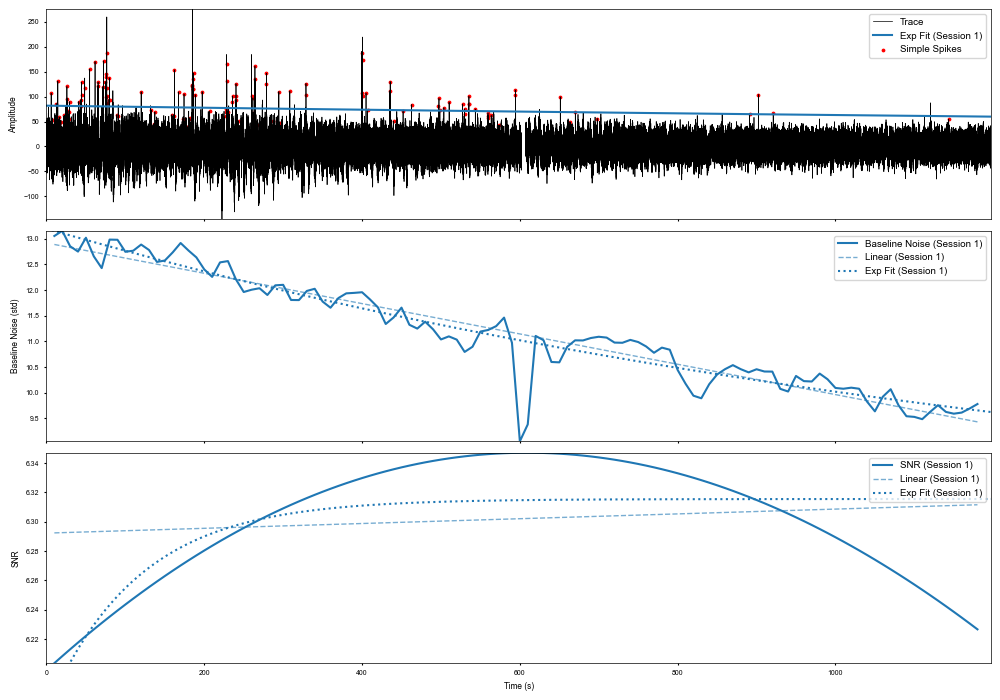

Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
  Found 60 complex spikes in segment 0
Total complex spikes detected: 60
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Removed 53 invalid CS bursts
Moved 8 spikes from single-spike bursts to refined_SS
Remaining CS bursts: 7
Created 3 pages with 240 segments total
Figure saved to: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/SNR_figures/cell_5_burst_detection.pdf

Processing cell 6
Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
Total complex spikes detected: 0
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Window size: 10000, Step size: 5000
Session 1 - Simple Spikes Linear slope: -0.011404
Session 1 - Simple Spikes Exp decay (b): 0.001441
Session 1 - Simple S

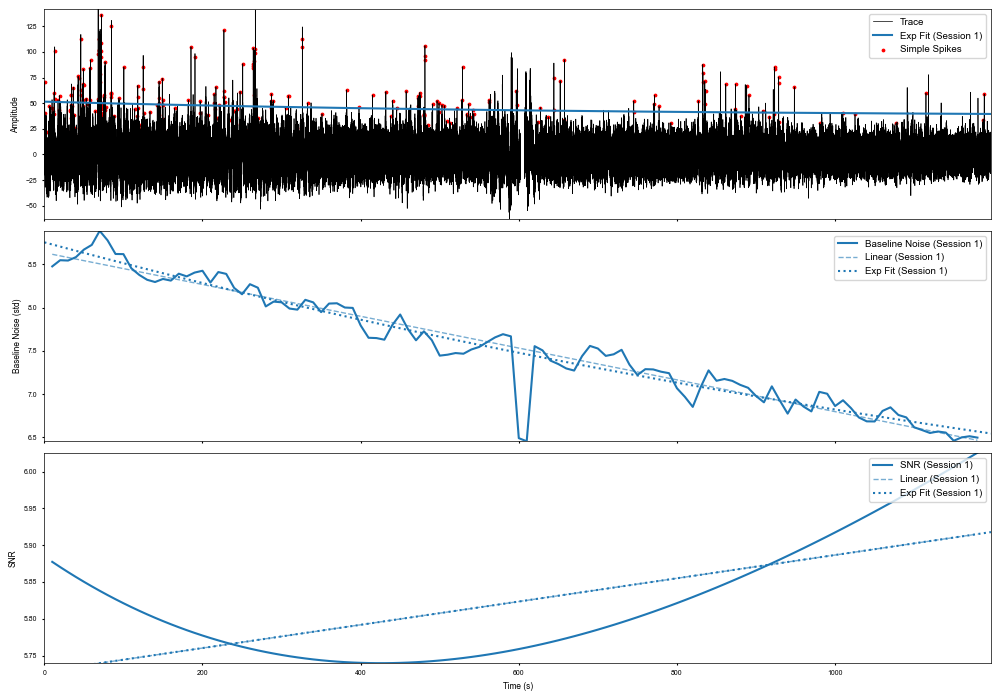

Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
  Found 106 complex spikes in segment 0
Total complex spikes detected: 106
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Removed 48 invalid CS bursts
Moved 6 spikes from single-spike bursts to refined_SS
Remaining CS bursts: 58
Created 3 pages with 240 segments total
Figure saved to: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/SNR_figures/cell_6_burst_detection.pdf

Processing cell 7
Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
  Found 6 complex spikes in segment 0
Total complex spikes detected: 6
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Window size: 10000, Step size: 5000
Session 1 - Simple Spikes Linear slope: -0.021372
Session 1 - Simple Spikes Exp

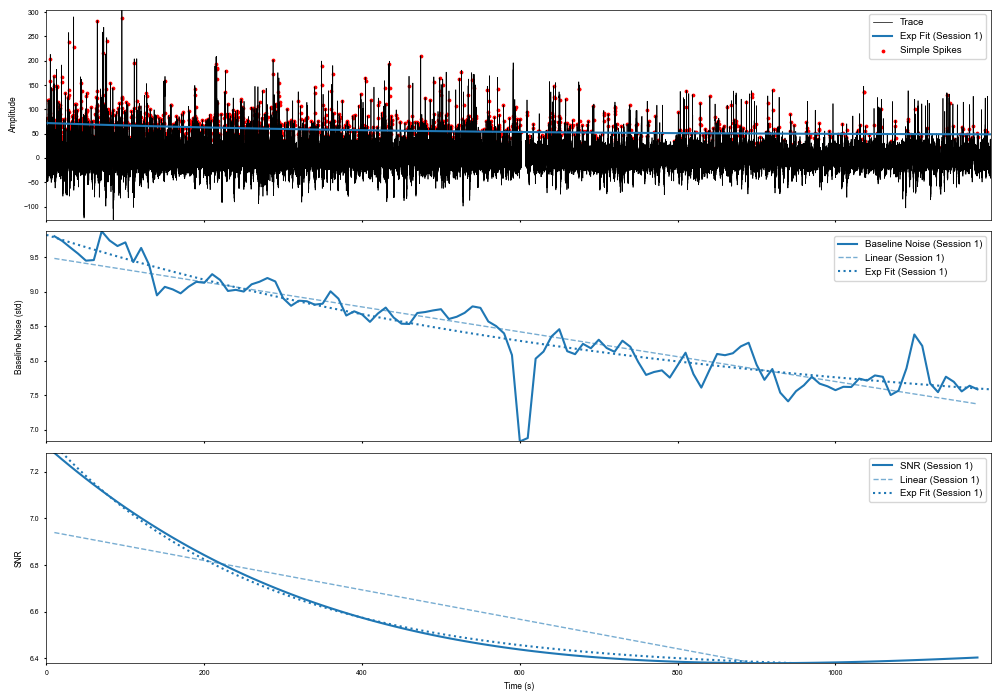

Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
  Found 272 complex spikes in segment 0
Total complex spikes detected: 272
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Removed 99 invalid CS bursts
Moved 21 spikes from single-spike bursts to refined_SS
Remaining CS bursts: 173
Created 3 pages with 240 segments total
Figure saved to: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/SNR_figures/cell_7_burst_detection.pdf

Processing cell 8
Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
Total complex spikes detected: 0
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Window size: 10000, Step size: 5000
Session 1 - Simple Spikes Linear slope: -0.027889
Session 1 - Simple Spikes Exp decay (b): 0.002128
Session 1 - Sim

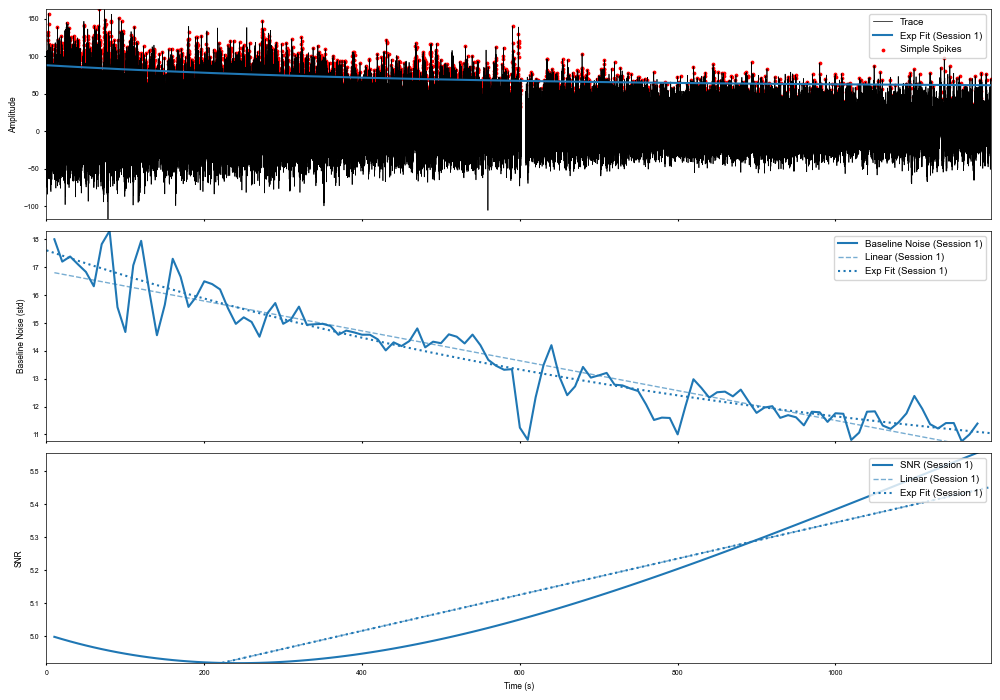

Trace length: 598579 frames
Processing trace in 1 segments for CS detection
Segment 0: 0 to 598579 (598579 frames)
  Found 32 complex spikes in segment 0
Total complex spikes detected: 32
Trace length: 598579 frames
Processing trace in 1 segments
Segment 0: 0 to 598579 (598579 frames)
Removed 30 invalid CS bursts
Moved 5 spikes from single-spike bursts to refined_SS
Remaining CS bursts: 2
Created 3 pages with 240 segments total
Figure saved to: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/SNR_figures/cell_8_burst_detection.pdf

Saved all results to: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/merged_aligned_data_CS.pkl


In [6]:
# Lists to store results for all cells
all_complex_bursts_dicts = []
all_refined_SS = []
all_CS_spikes_list = []
all_spikes_list = []
all_spike_heights_interpolated = []
all_SNR_interpolated = []
all_traces_SNR_interpolated = []
all_Vm_SNR_interpolated = []
all_burst_metrics = []
all_plateaus_dicts = []

for idx in range(traces.shape[0]):
    print(f"\n{'='*50}")
    print(f"Processing cell {idx}")
    print(f"{'='*50}")

    trace_idx = traces[idx, :]
    spike_idx = spikes_volpy[idx]

    figure_folder = os.path.join(main_data_folder, 'SNR_figures')

    if not os.path.exists(figure_folder):
        os.makedirs(figure_folder)
    # Plot and save as PDF
    save_path_pdf = os.path.join(figure_folder, f'cell_{idx}_burst_detection.pdf')
    # delete if exists
    if os.path.exists(save_path_pdf):
        os.remove(save_path_pdf)

    with PdfPages(save_path_pdf) as pdf:
        separate_by_sessions = False

        baseline_window = int(frame_rate * 10)  # 20 seconds window

        CB_detection_method = 'simple' # 'simple' or 'volpy_based'
        SS_detection_method = 'simple' # 'simple' or 'volpy_based'

        # parameters for volpy-based complex burst detection
        pnorm_CS = 0.25
        process_window_CS = 300000  # in seconds

        # parameters for simple complex burst detection
        simple_threshold = 6  # in mad units

        # parameters for volpy-based simple spike refinement
        pnorm_SS = 0.25
        process_window_SS = 300000  # in seconds

        # parameter for simple SS refinement
        simple_threshold_SS = 6  # in mad units
        f_hp = 20  # high-pass filter cutoff frequency for SS refinement

        # highpass filter cutoff for CS detection (set to None to skip)
        f_hp_CS = 1  # Hz

        # session_start_frames to pass (None when not separating by sessions)
        session_frames = session_start_frames if separate_by_sessions else None

        # Step 0: median filter the trace with a large window to get the baseline, then remove it from the original trace
        nan_mask = np.isnan(trace_idx)
        trace_baseline = median_filter(interpolate_nan_segment(trace_idx), size=baseline_window)
        trace_idx = trace_idx - trace_baseline
        trace_idx[nan_mask] = np.nan

        # Round 1: We want to have a rough estimate of the spike height, we set the simple_threshold really high to make sure almost no CB is detected
        complex_bursts_dict, segment_bounds = complex_bursts_detection(trace_idx, spike_idx, frame_rate, pnorm=pnorm_CS, process_window=process_window_CS, 
                                                                    plotflag=False, CB_detection_method=CB_detection_method, simple_threshold=50
                                                                    , separate_by_sessions=separate_by_sessions, session_start_frames=session_start_frames, f_hp=f_hp_CS)

        refined_SS, trace_noCS = refine_single_spikes(trace_idx, spike_idx, complex_bursts_dict, frame_rate, process_window=process_window_SS, pnorm=pnorm_SS, f_hp=f_hp, min_spikes=10, plotflag=False,
                                                    separate_by_sessions=separate_by_sessions, session_start_frames=session_start_frames, SS_detection_method=SS_detection_method, simple_threshold_SS=simple_threshold_SS)

        spike_idx = refined_SS

        spike_heights_interpolated, SNR_interpolated = spike_height_calculation2(refined_SS, trace_idx, complex_bursts_dict['trace_mf'], trace_noCS, frame_rate, plotflag=True, session_start_frames=session_frames, pdf=pdf)
        
        # Round 2
        CB_detection_method = 'simple' # 'simple' or 'volpy_based'
        SS_detection_method = 'simple' # 'simple' or 'volpy_based'
        SS_height_cap = 0.6
        complex_spike_threshold = [0.8, 0.6]

        highpass = 2  # Hz
        median_window = 11
        cb_amp_threshold = 0.6
        cb_duration_threshold = 20  # in ms
        plateau_amp_threshold = 0.8
        plateau_duration_threshold = 100  # in ms
        plateau_kernel_ms = 100  # boxcar kernel width for plateau detection
        plateau_score_min_ms = 80  # min duration score must exceed threshold
        isi_threshold_ms = 20

        trace_idx = trace_idx/spike_heights_interpolated

        complex_bursts_dict, segment_bounds = complex_bursts_detection(trace_idx, spike_idx, frame_rate, pnorm=pnorm_CS, process_window=process_window_CS, 
                                                                    plotflag=False, CB_detection_method=CB_detection_method, simple_threshold=simple_threshold
                                                                    , separate_by_sessions=separate_by_sessions, session_start_frames=[0], f_hp=f_hp_CS)

        refined_SS, trace_noCS = refine_single_spikes(trace_idx, spike_idx, complex_bursts_dict, frame_rate, process_window=process_window_SS, pnorm=pnorm_SS, f_hp=f_hp, min_spikes=10, plotflag=False,
                                                    separate_by_sessions=separate_by_sessions, session_start_frames=[0], SS_detection_method=SS_detection_method, 
                                                    simple_threshold_SS=simple_threshold_SS, SS_height_cap=SS_height_cap)

        CS_spikes = detect_complex_spikes(trace_idx, complex_bursts_dict, np.ones_like(trace_idx), threshold=complex_spike_threshold, plotflag=False)

        complex_bursts_dict, refined_SS, all_CS_spikes, all_spikes = refine_all_spikes(complex_bursts_dict, CS_spikes, refined_SS)

        simple_spikes_final, complex_spikes_final, all_spikes_final, trace_SNR_interpolated, Vm, burst_metrics, complex_bursts_dict_vm, plateaus_dict = detect_bursts_from_vm(
            trace_idx,
            np.ones_like(trace_idx),
            complex_bursts_dict,
            all_spikes,
            fr,
            highpass=highpass,
            median_window=median_window,
            cb_amp_threshold=cb_amp_threshold,
            cb_duration_threshold=cb_duration_threshold,
            isi_threshold_ms=isi_threshold_ms,
            baseline_subtract=False, # for each burst, calculate a local baseline and subtract
            baseline_window_ms=20,      # pre-start window
            baseline_percentile=None,     # set to None to use min
            merge_SS_ms = None,
            merge_CB_ms = None,
            plateau_amp_threshold=plateau_amp_threshold,
            plateau_duration_threshold=plateau_duration_threshold,
            plateau_kernel_ms=plateau_kernel_ms,
            plateau_score_min_ms=plateau_score_min_ms,
            pdf=pdf,
        )

        # Store results for this cell
        all_complex_bursts_dicts.append(complex_bursts_dict_vm)
        all_refined_SS.append(simple_spikes_final)
        all_CS_spikes_list.append(complex_spikes_final)
        all_spikes_list.append(all_spikes_final)
        all_spike_heights_interpolated.append(spike_heights_interpolated)
        all_SNR_interpolated.append(SNR_interpolated)
        all_traces_SNR_interpolated.append(trace_SNR_interpolated)
        all_Vm_SNR_interpolated.append(Vm)
        all_burst_metrics.append(burst_metrics)
        all_plateaus_dicts.append(plateaus_dict)

        plot_trace_with_bursts_pdf(trace_SNR_interpolated, Vm, simple_spikes_final, complex_spikes_final, complex_bursts_dict_vm, fr,
                                   segment_duration=5, rows_per_page=100, pdf=pdf, plateaus_dict=plateaus_dict)
        plot_burst_metrics_pdf(burst_metrics, pdf=pdf, figsize=(6, 3))
    
    print('Figure saved to:', save_path_pdf)

# Save all results along with original data
save_data = loaded_merged_data.copy()
save_data['complex_bursts_dicts'] = all_complex_bursts_dicts
save_data['refined_SS'] = all_refined_SS
save_data['all_CS_spikes'] = all_CS_spikes_list
save_data['all_spikes'] = all_spikes_list
save_data['spike_heights_interpolated'] = all_spike_heights_interpolated
save_data['SNR_interpolated'] = all_SNR_interpolated
save_data['traces_SNR_interpolated'] = all_traces_SNR_interpolated
save_data['Vm_SNR_interpolated'] = all_Vm_SNR_interpolated
save_data['burst_metrics'] = all_burst_metrics
save_data['plateaus_dicts'] = all_plateaus_dicts
save_data['CS_detection_params'] = {
    'pnorm_CS': pnorm_CS,
    'pnorm_SS': pnorm_SS,
    'process_window_CS': process_window_CS,
    'process_window_SS': process_window_SS,
    'complex_spike_threshold': complex_spike_threshold
}
save_data['CB_detection_params'] = {
    'cb_amp_threshold': cb_amp_threshold,
    'cb_duration_threshold': cb_duration_threshold,
    'isi_threshold_ms': isi_threshold_ms,
    'plateau_amp_threshold': plateau_amp_threshold,
    'plateau_duration_threshold': plateau_duration_threshold,
    'plateau_kernel_ms': plateau_kernel_ms,
    'plateau_score_min_ms': plateau_score_min_ms,
}

save_path = os.path.join(main_data_folder, 'merged_aligned_data_CS.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(save_data, f)

print(f"\n{'='*50}")
print(f"Saved all results to: {save_path}")
print(f"{'='*50}")

In [6]:
print('Figure saved to:', save_path_pdf)

Figure saved to: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/SNR_figures/cell_8_burst_detection.pdf


In [7]:
# highpass = 1  # Hz
# median_window = 11
# CB_amp_threshold = 0.3
# CB_duration_threshold = 20  # in ms
# isi_threshold_ms = 20

# simple_spikes_all, complex_spikes, all_spikes, trace_SNR_interpolated, Vm, burst_metrics = detect_bursts_from_vm(
#     trace_idx,
#     spike_heights_interpolated,
#     complex_bursts_dict,
#     all_spikes,
#     fr,
#     highpass=highpass,
#     median_window=median_window,
#     cb_amp_threshold=CB_amp_threshold,
#     cb_duration_threshold=CB_duration_threshold,
#     isi_threshold_ms=isi_threshold_ms,
# )

# complex_bursts = [(b['start'], b['end']) for b in burst_metrics if b.get('is_complex') and b['n_spikes'] > 1]

# burst_figure_folder = os.path.join(main_data_folder, 'SNR_figures')
# if not os.path.exists(burst_figure_folder):
#     os.makedirs(burst_figure_folder)

# save_path_burst_pdf = os.path.join(burst_figure_folder, f'cell_{idx}_burst_detection.pdf')

# from matplotlib.backends.backend_pdf import PdfPages
# with PdfPages(save_path_burst_pdf) as pdf:
#     plot_trace_with_bursts_pdf(trace_SNR_interpolated, Vm, simple_spikes_all, complex_spikes, complex_bursts, fr, segment_duration=10, rows_per_page=20, pdf=pdf)

#     burst_n_spikes = np.array([b['n_spikes'] for b in burst_metrics], dtype=float)
#     burst_amp = np.array([b['peak_amp'] for b in burst_metrics], dtype=float)
#     burst_dur = np.array([b['duration_ms'] for b in burst_metrics], dtype=float)
#     burst_auc = np.array([b['auc'] for b in burst_metrics], dtype=float)
#     burst_is_complex = np.array([b['is_complex'] for b in burst_metrics], dtype=bool)

#     fig, axes = plt.subplots(1, 2, figsize=(6, 3))

#     # Amplitude vs duration
#     if len(burst_amp) > 0:
#         axes[0].scatter(burst_dur[~burst_is_complex], burst_amp[~burst_is_complex], color='gray', s=15, label='Simple')
#         axes[0].scatter(burst_dur[burst_is_complex], burst_amp[burst_is_complex], color='magenta', s=20, label='Complex')
#     axes[0].set_xlabel('Duration (ms)')
#     axes[0].set_ylabel('Peak amplitude')
#     axes[0].legend(fontsize=7, loc='upper right')

#     # AUC vs number of spikes
#     if len(burst_auc) > 0:
#         axes[1].scatter(burst_n_spikes[~burst_is_complex], burst_auc[~burst_is_complex], color='gray', s=15, label='Simple')
#         axes[1].scatter(burst_n_spikes[burst_is_complex], burst_auc[burst_is_complex], color='magenta', s=20, label='Complex')

#     def _mean_sem(vals):
#         vals = np.asarray(vals, dtype=float)
#         vals = vals[np.isfinite(vals)]
#         if len(vals) == 0:
#             return np.nan, np.nan
#         return np.nanmean(vals), np.nanstd(vals) / np.sqrt(len(vals))

#     unique_counts = np.unique(burst_n_spikes[np.isfinite(burst_n_spikes)])
#     means_simple = []
#     sems_simple = []
#     means_complex = []
#     sems_complex = []
#     means_all = []
#     sems_all = []
#     for count in unique_counts:
#         simple_vals = burst_auc[(burst_n_spikes == count) & (~burst_is_complex)]
#         complex_vals = burst_auc[(burst_n_spikes == count) & (burst_is_complex)]
#         all_vals = burst_auc[burst_n_spikes == count]
#         mean_s, sem_s = _mean_sem(simple_vals)
#         mean_c, sem_c = _mean_sem(complex_vals)
#         mean_a, sem_a = _mean_sem(all_vals)
#         means_simple.append(mean_s)
#         sems_simple.append(sem_s)
#         means_complex.append(mean_c)
#         sems_complex.append(sem_c)
#         means_all.append(mean_a)
#         sems_all.append(sem_a)

#     unique_counts = np.array(unique_counts, dtype=float)
#     means_simple = np.array(means_simple, dtype=float)
#     sems_simple = np.array(sems_simple, dtype=float)
#     means_complex = np.array(means_complex, dtype=float)
#     sems_complex = np.array(sems_complex, dtype=float)
#     means_all = np.array(means_all, dtype=float)
#     sems_all = np.array(sems_all, dtype=float)

#     if len(unique_counts) > 0:
#         axes[1].errorbar(unique_counts, means_simple, yerr=sems_simple, color='gray', linestyle='-', marker='o', markersize=4, capsize=3, label='Simple mean ± s.e.m.')
#         axes[1].errorbar(unique_counts, means_complex, yerr=sems_complex, color='magenta', linestyle='-', marker='o', markersize=4, capsize=3, label='Complex mean ± s.e.m.')
#         axes[1].errorbar(unique_counts, means_all, yerr=sems_all, color='black', linestyle='-', marker='o', markersize=4, capsize=3, label='All mean ± s.e.m.')

#     axes[1].set_xlabel('Number of spikes')
#     axes[1].set_ylabel('AUC')
#     axes[1].legend(fontsize=7, loc='upper right')

#     plt.tight_layout()
#     pdf.savefig(fig, bbox_inches='tight')
#     plt.close(fig)

#     print(f"Saved burst metrics figure to: {save_path_burst_pdf}")

# # fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
# # axes[0].plot(trace_idx, color='gray',linewidth=0.5)

# # axes[1].plot(trace_SNR_interpolated, color='gray',linewidth=0.5)
# # axes[1].plot(Vm, color='blue', linewidth=1)
# # axes[1].plot(Vm_noCS, color='red', linewidth=1)
# # axes[1].axhline(CB_amp_threshold, color='green', linestyle='--')
# # if len(simple_spikes_all) > 0:
# #     axes[1].scatter(simple_spikes_all, trace_SNR_interpolated[simple_spikes_all], color='black', s=5, label='Simple spikes')
# # if len(complex_spikes) > 0:
# #     axes[1].scatter(complex_spikes, trace_SNR_interpolated[complex_spikes], color='magenta', s=8, label='Complex spikes')
# # for i, (start, end) in enumerate(complex_bursts):
# #     axes[1].axvspan(start, end, color='yellow', alpha=0.2, label='Complex burst' if i == 0 else None)

# # axes[1].legend(loc='upper right', fontsize=7)

# # axes[2].plot(trace_SNR_interpolated, color='gray',linewidth=0.5)
# # if len(complex_spikes) > 0:
# #     axes[2].scatter(complex_spikes, trace_SNR_interpolated[complex_spikes], color='magenta', s=8, label='Complex spikes')
# # for i, (start, end) in enumerate(complex_bursts):
# #     axes[2].axvspan(start, end, color='yellow', alpha=0.2, label='Complex burst' if i == 0 else None)
# # axes[2].legend(loc='upper right', fontsize=7)


In [8]:
import subprocess
subprocess.run(['open', figure_folder])

CompletedProcess(args=['open', '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/SNR_figures'], returncode=0)

In [9]:
import ipywidgets as widgets
from IPython.display import display, clear_output, FileLink
from matplotlib.backends.backend_pdf import PdfPages
import subprocess
import os
import pickle

if 'cell_params' not in globals():
    cell_params = {}
if 'cell_results' not in globals():
    cell_results = {}


def _get_default_params():
    return {
        'pnorm_CS': 0.25,
        'process_window_CS': 600,
        'pnorm_SS': 0.25,
        'process_window_SS': 600,
        'complex_spike_threshold': 0.5,
        'highpass': 1.0,
        'median_window': 11,
        'cb_amp_threshold': 0.3,
        'cb_duration_threshold': 20,
        'isi_threshold_ms': 20,
        'plateau_amp_threshold': 0.5,
        'plateau_duration_threshold': 100,
        'plateau_kernel_ms': 100,
        'plateau_score_min_ms': 20,
    }


def _get_frame_rate():
    return frame_rate if 'frame_rate' in globals() else fr


DEFAULT_PARAMS = _get_default_params()
if 'global_params' not in globals():
    global_params = DEFAULT_PARAMS.copy()
else:
    for key, val in DEFAULT_PARAMS.items():
        global_params.setdefault(key, val)


def process_cell(idx, params, open_pdf=True):
    fr_local = _get_frame_rate()
    trace_idx = traces[idx, :]
    spike_idx = spikes_volpy[idx]

    complex_bursts_dict, _ = complex_bursts_detection(
        trace_idx,
        spike_idx,
        fr_local,
        pnorm=params['pnorm_CS'],
        process_window=params['process_window_CS'],
        plotflag=True,
    )

    refined_SS, trace_noCS = refine_single_spikes(
        trace_idx,
        spike_idx,
        complex_bursts_dict,
        fr_local,
        process_window=params['process_window_SS'],
        pnorm=params['pnorm_SS'],
        min_spikes=10,
        plotflag=False,
    )

    figure_folder = os.path.join(main_data_folder, 'SNR_figures')
    os.makedirs(figure_folder, exist_ok=True)
    save_path_pdf = os.path.join(figure_folder, f'cell_{idx}_burst_detection.pdf')
    if os.path.exists(save_path_pdf):
        os.remove(save_path_pdf)

    session_frames = session_start_frames if 'session_start_frames' in globals() else None

    with PdfPages(save_path_pdf) as pdf:
        spike_heights_interpolated, SNR_interpolated = spike_height_calculation2(
            refined_SS,
            trace_idx,
            complex_bursts_dict['trace_mf'],
            trace_noCS,
            fr_local,
            plotflag=True,
            session_start_frames=session_frames,
            pdf=pdf,
            plateaus_dict=plateaus_dict,
        )

        CS_spikes = detect_complex_spikes(
            trace_idx,
            complex_bursts_dict,
            spike_heights_interpolated,
            threshold=params['complex_spike_threshold'],
            plotflag=False,
        )

        complex_bursts_dict, refined_SS, all_CS_spikes, all_spikes = refine_all_spikes(
            complex_bursts_dict,
            CS_spikes,
            refined_SS,
        )

        simple_spikes_final, complex_spikes_final, all_spikes_final, trace_SNR_interpolated, Vm, burst_metrics, complex_bursts_dict_vm, plateaus_dict = detect_bursts_from_vm(
            trace_idx,
            spike_heights_interpolated,
            complex_bursts_dict,
            all_spikes,
            fr_local,
            highpass=params['highpass'],
            median_window=params['median_window'],
            cb_amp_threshold=params['cb_amp_threshold'],
            cb_duration_threshold=params['cb_duration_threshold'],
            isi_threshold_ms=params['isi_threshold_ms'],
            plateau_amp_threshold=params['plateau_amp_threshold'],
            plateau_duration_threshold=params['plateau_duration_threshold'],
            plateau_kernel_ms=params['plateau_kernel_ms'],
            plateau_score_min_ms=params['plateau_score_min_ms'],
            pdf=pdf,
        )

        plot_trace_with_bursts_pdf(
            trace_SNR_interpolated,
            Vm,
            simple_spikes_final,
            complex_spikes_final,
            complex_bursts_dict_vm,
            fr_local,
            segment_duration=10,
            rows_per_page=20,
            pdf=pdf,
        )
        plot_burst_metrics_pdf(burst_metrics, pdf=pdf, figsize=(6, 3))

    if open_pdf:
        try:
            subprocess.run(['open', save_path_pdf])
        except Exception as exc:
            print(f'Could not open PDF automatically: {exc}')

    results = {
        'complex_bursts_dict_vm': complex_bursts_dict_vm,
        'refined_SS': simple_spikes_final,
        'all_CS_spikes': complex_spikes_final,
        'all_spikes': all_spikes_final,
        'spike_heights_interpolated': spike_heights_interpolated,
        'SNR_interpolated': SNR_interpolated,
        'trace_SNR_interpolated': trace_SNR_interpolated,
        'Vm': Vm,
        'burst_metrics': burst_metrics,
        'plateaus_dict': plateaus_dict,
        'save_path_pdf': save_path_pdf,
    }
    return results


def save_all_results():
    n_cells = traces.shape[0]

    def _init_list():
        return [None] * n_cells

    all_complex_bursts_dicts = _init_list()
    all_refined_SS = _init_list()
    all_CS_spikes_list = _init_list()
    all_spikes_list = _init_list()
    all_spike_heights_interpolated = _init_list()
    all_SNR_interpolated = _init_list()
    all_traces_SNR_interpolated = _init_list()
    all_Vm_SNR_interpolated = _init_list()
    all_burst_metrics = _init_list()
    all_plateaus_dicts = _init_list()

    for idx, res in cell_results.items():
        all_complex_bursts_dicts[idx] = res['complex_bursts_dict_vm']
        all_refined_SS[idx] = res['refined_SS']
        all_CS_spikes_list[idx] = res['all_CS_spikes']
        all_spikes_list[idx] = res['all_spikes']
        all_spike_heights_interpolated[idx] = res['spike_heights_interpolated']
        all_SNR_interpolated[idx] = res['SNR_interpolated']
        all_traces_SNR_interpolated[idx] = res['trace_SNR_interpolated']
        all_Vm_SNR_interpolated[idx] = res['Vm']
        all_burst_metrics[idx] = res['burst_metrics']
        all_plateaus_dicts[idx] = res['plateaus_dict']

    save_data = loaded_merged_data.copy()
    save_data['complex_bursts_dicts'] = all_complex_bursts_dicts
    save_data['refined_SS'] = all_refined_SS
    save_data['all_CS_spikes'] = all_CS_spikes_list
    save_data['all_spikes'] = all_spikes_list
    save_data['spike_heights_interpolated'] = all_spike_heights_interpolated
    save_data['SNR_interpolated'] = all_SNR_interpolated
    save_data['traces_SNR_interpolated'] = all_traces_SNR_interpolated
    save_data['Vm_SNR_interpolated'] = all_Vm_SNR_interpolated
    save_data['burst_metrics'] = all_burst_metrics
    save_data['plateaus_dicts'] = all_plateaus_dicts
    save_data['params_by_cell'] = cell_params
    save_data['global_params'] = global_params

    save_path = os.path.join(main_data_folder, 'merged_aligned_data_CS.pkl')
    with open(save_path, 'wb') as f:
        pickle.dump(save_data, f)

    return save_path


cell_selector = widgets.Dropdown(options=list(range(traces.shape[0])), description='Cell:')

param_widgets = {
    'pnorm_CS': widgets.FloatText(description='pnorm_CS'),
    'process_window_CS': widgets.IntText(description='process_window_CS'),
    'pnorm_SS': widgets.FloatText(description='pnorm_SS'),
    'process_window_SS': widgets.IntText(description='process_window_SS'),
    'complex_spike_threshold': widgets.FloatText(description='complex_spike_threshold'),
    'highpass': widgets.FloatText(description='highpass'),
    'median_window': widgets.IntText(description='median_window'),
    'cb_amp_threshold': widgets.FloatText(description='cb_amp_threshold'),
    'cb_duration_threshold': widgets.FloatText(description='cb_duration_threshold'),
    'isi_threshold_ms': widgets.IntText(description='isi_threshold_ms'),
    'plateau_amp_threshold': widgets.FloatText(description='plateau_amp_thr'),
    'plateau_duration_threshold': widgets.FloatText(description='plateau_dur_thr'),
    'plateau_kernel_ms': widgets.FloatText(description='plateau_kernel'),
    'plateau_score_min_ms': widgets.FloatText(description='plateau_score_min'),
}


def _load_params(idx):
    params = cell_params.get(idx, global_params)
    for key, widget in param_widgets.items():
        widget.value = params.get(key, DEFAULT_PARAMS[key])


cell_selector.observe(lambda change: _load_params(change['new']), names='value')
_load_params(cell_selector.value)

run_button = widgets.Button(description='Run Cell', button_style='success')
run_all_button = widgets.Button(description='Run All Cells', button_style='warning')
save_button = widgets.Button(description='Save All', button_style='info')
open_checkbox = widgets.Checkbox(value=True, description='Open PDF after run')
output = widgets.Output()


def _collect_params():
    return {key: widget.value for key, widget in param_widgets.items()}


def on_run_clicked(_):
    idx = cell_selector.value
    params = _collect_params()
    cell_params[idx] = dict(params)
    with output:
        clear_output()
        print(f'Running cell {idx}...')
        results = process_cell(idx, params, open_pdf=open_checkbox.value)
        cell_results[idx] = results
        print(f"PDF saved: {results['save_path_pdf']}")
        display(FileLink(results['save_path_pdf']))


def on_run_all_clicked(_):
    global global_params
    params = _collect_params()
    global_params = dict(params)
    n_cells = traces.shape[0]
    with output:
        clear_output()
        print('Running all cells with shared parameters...')
        for idx in range(n_cells):
            print(f'Processing cell {idx}...')
            results = process_cell(idx, params, open_pdf=False)
            cell_results[idx] = results
            cell_params[idx] = dict(params)
        print('Done.')


def on_save_clicked(_):
    n_cells = traces.shape[0]
    missing = [idx for idx in range(n_cells) if idx not in cell_results]
    with output:
        clear_output()
        if missing:
            print(f'Missing results for cells: {missing}')
            print('Run all cells first, then re-run any special cells you tuned.')
            return
        save_path = save_all_results()
        print(f'Saved merged results to: {save_path}')
        display(FileLink(save_path))


run_button.on_click(on_run_clicked)
run_all_button.on_click(on_run_all_clicked)
save_button.on_click(on_save_clicked)

param_box = widgets.VBox([
    cell_selector,
    *list(param_widgets.values()),
    open_checkbox,
    widgets.HBox([run_button, run_all_button, save_button]),
])

display(param_box, output)


Output()

# Make demo video (uses merged_aligned_data_CS.pkl with refined spikes)

In [ ]:
from utils.demo_video_with_neural import make_demo_video_concat

# --- Tunable parameters ---
cells_display = [0, 1, 3, 4, 5, 6] # pAce38
output_fps = 20
neural_step = 25

make_demo_video_concat(
    main_data_folder,
    cells_display=cells_display,
    speed_threshold=3,
    output_fps=output_fps,
    neural_step=neural_step,
    width_real=35.5,
    height_real=20.0,
    display_window=1000,
    output_name="place_cell_activity_video.mp4",
)

Loaded merged data from /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/merged_aligned_data_CS.pkl
Total neural frames: 598579, sessions: 2
  Session 0: frames [0:299257] (299257 frames)
  Session 1: frames [299257:598579] (299322 frames)
Loading per-session behavior data and videos...
  Session 0: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/2-good
    Video: Flir-02222026114019-0000.avi


## Submit demo video job to cluster

In [ ]:
import paramiko
import re

CLUSTER_HOST = 'loginserver.elsc.huji.ac.il'
USERNAME = 'qixin.yang'
SSH_KEY_PATH = os.path.expanduser('~/.ssh/id_rsa')

PIPELINE_WORKDIR = '/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4'
sh_script = '/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/run_python_job.sh'
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
kwargs = {}
if SSH_KEY_PATH and os.path.exists(SSH_KEY_PATH):
    kwargs['key_filename'] = SSH_KEY_PATH
ssh.connect(CLUSTER_HOST, username=USERNAME, **kwargs)
print('[INFO] Connected to cluster.')

[INFO] Connected to cluster.


In [ ]:
# Sync local Python files to cluster code directory
import shutil

LOCAL_UTILS = os.path.join(parent_dir, 'utils')
REMOTE_UTILS = '/Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils'

files_to_sync = [
    'demo_video_with_neural.py',
    'make_demo_video_concat_job.py',
    'preprocess_neural.py',
    'preprocess_behavior.py',
    'spike_detection.py',
]

for fname in files_to_sync:
    src = os.path.join(LOCAL_UTILS, fname)
    dst = os.path.join(REMOTE_UTILS, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"  Synced {fname}")
    else:
        print(f"  SKIP (not found): {fname}")

print("Done syncing files.")

  Synced demo_video_with_neural.py
  Synced make_demo_video_concat_job.py
  Synced preprocess_neural.py
  Synced preprocess_behavior.py
  Synced spike_detection.py
Done syncing files.


In [ ]:
# Submit concat demo video job to cluster (reuses ssh from earlier cell)
python_script = 'utils/make_demo_video_concat_job.py'
JOB_NAME = 'demo_concat'
CONDA_ENV = 'caiman'

# --- Tunable ---
#cells_display = [0, 2, 3, 4] # pAce47
cells_display = [0, 1, 3, 4, 5, 6] # pAce38
output_fps = 20
neural_step = 25

# Convert local path to cluster path
remote_data = main_data_folder.replace('/Volumes/adam-lab/', '/ems/elsc-labs/adam-y/')
cells_str = ' '.join(str(c) for c in cells_display)

# Ensure log dir exists
ssh.exec_command(f"bash -l -c 'mkdir -p {LOG_DIR}'")

cmd = (
    f"sbatch --job-name {JOB_NAME} --mem=32G -c 4 -t 4:00:00 "
    f"--export=ALL,CONDA_ENV_NAME={CONDA_ENV} "
    f"--chdir {PIPELINE_WORKDIR} "
    f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
    f"{sh_script} {PIPELINE_WORKDIR} {python_script} "
    f"{remote_data} "
    f"--cells {cells_str} "
    f"--output-fps {output_fps} --neural-step {neural_step}"
)
full_cmd = f"bash -l -c '{cmd}'"

print("Submitting:", cmd)
stdin, stdout, stderr = ssh.exec_command(full_cmd)
output = stdout.read().decode().strip()
error = stderr.read().decode().strip()

if error and 'Submitted' not in output:
    print(f"[ERROR] {error}")
else:
    print(f"[INFO] {output}")

LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
print(f"Logs: {LOG_DIR_LOCAL}")

Submitting: sbatch --job-name demo_concat --mem=32G -c 4 -t 4:00:00 --export=ALL,CONDA_ENV_NAME=caiman --chdir /ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4 --output /ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/logs/%x_%j.out --error /ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/logs/%x_%j.err /ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/run_python_job.sh /ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4 utils/make_demo_video_concat_job.py /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake --cells 0 1 3 4 5 6 --output-fps 20 --neural-step 25
[INFO] Submitted batch job 18167277
Logs: /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/logs


In [ ]:
# Check job log (reuses ssh from earlier cell)
cmd = f"ls -t {LOG_DIR}/demo_concat_*.out 2>/dev/null | head -1"
_, stdout, _ = ssh.exec_command(f"bash -l -c '{cmd}'")
log_file = stdout.read().decode().strip()

if log_file:
    print(f"Log: {log_file}")
    _, stdout, _ = ssh.exec_command(f"bash -l -c 'tail -40 {log_file}'")
    print(stdout.read().decode())
else:
    print("No log file found yet. Job may still be queued.")
    _, stdout, _ = ssh.exec_command("bash -l -c 'squeue -u qixin.yang'")
    print(stdout.read().decode())

Log: /ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/logs/demo_concat_17998345.out
Starting Python: utils/make_demo_video_concat_job.py
Workdir: /ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4
Args: /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake --cells 0 1 3 4 5 6 --output-fps 20 --neural-step 25
Current working directory: /ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4
Python executable: /ems/elsc-labs/adam-y/qixin.yang/anaconda3/envs/caiman/bin/python
Python 3.6.13
Main data folder: /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake
Cells: [0, 1, 3, 4, 5, 6]
Loaded merged data from /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake/merged_aligned_data_CS.pkl

